In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

df = pd.read_parquet("../../data/05_metrics/graph_metrics_df.parquet")
# df_sector = pd.read_parquet("../../data/01_raw/screener_result.parquet")[["Ticker", "Sector", "Market Cap"]]
# df = df.merge(df_sector, how="left", left_on="node", right_on="Ticker").drop(columns="Ticker")

In [2]:
import os
import pandas as pd
import numpy as np

base_returns = "../../data/02_clean"
min_obs = 5

monthly_metrics = []

base_modes = "../../data/03_modes"

# Listar todos os arquivos returns_YYYY_MM.parquet
year_months = sorted([
    d for d in os.listdir(base_modes)
    if "_" in d and os.path.isdir(os.path.join(base_modes, d))
])

for ym in year_months:
    returns = pd.read_parquet(f"{base_returns}/returns_{ym}.parquet")

    # --- Monthly return (compound, preserving NaNs) ---
    monthly_return = (
        returns.apply(
            lambda x: (1 + x.dropna()).prod() - 1
            if x.notna().sum() >= min_obs else np.nan
        )
        .to_frame(name="monthly_return")
    )

    # --- Monthly volatility ---
    monthly_volatility = (
        returns.std()
        .to_frame(name="monthly_volatility")
    )

    # Merge
    df_month = (
        monthly_return
        .merge(monthly_volatility, left_index=True, right_index=True)
        .reset_index()
        .rename(columns={"index": "node"})
    )

    df_month["year_month"] = ym

    monthly_metrics.append(df_month)

# Concatenar tudo
monthly_metrics_df = pd.concat(monthly_metrics, ignore_index=True)

In [3]:
df = df.merge(monthly_metrics_df, left_on=["node", "year_month"], 
         right_on=["Ticker", "year_month"], how="left")

## Tabelas

In [5]:
df[df['speed']=='Fast'][["degree", "nodal_resistance", "weighted_clustering",
                         "betweenness", "eigenvector", "closeness",
                         "monthly_return", "monthly_volatility",]].corr()[["monthly_return", "monthly_volatility"]].iloc[:6]

,monthly_return,monthly_volatility
degree,0.053692,0.444665
nodal_resistance,-0.029242,0.011162
weighted_clustering,-0.039814,-0.073385
betweenness,0.077177,0.166986
eigenvector,0.059123,0.288510
closeness,0.016582,-0.033030


In [6]:
df[df['speed']=='Medium'][["degree", "nodal_resistance", "weighted_clustering",
                         "betweenness", "eigenvector", "closeness",
                         "monthly_return", "monthly_volatility",]].corr()[["monthly_return", "monthly_volatility"]].iloc[:6]

,monthly_return,monthly_volatility
degree,0.053250,0.454361
nodal_resistance,-0.027420,-0.054741
weighted_clustering,-0.033675,-0.151353
betweenness,0.035160,0.184090
eigenvector,0.041611,0.304447
closeness,0.007211,0.018364


In [7]:
df[df['speed']=='Slow'][["degree", "nodal_resistance", "weighted_clustering",
                         "betweenness", "eigenvector", "closeness",
                         "monthly_return", "monthly_volatility",]].corr()[["monthly_return", "monthly_volatility"]].iloc[:6]

,monthly_return,monthly_volatility
degree,0.069026,0.486438
nodal_resistance,-0.022198,-0.057256
weighted_clustering,-0.032195,-0.163406
betweenness,0.039509,0.208559
eigenvector,0.053892,0.348171
closeness,0.011640,0.018644


## Top n

In [237]:
def build_sparse_portfolio(metric, n, mode, RET_CAP=50):
    top_n = {}
    bottom_n = {}

    for i in range(1, len(year_months)):
        ym_prev = year_months[i - 1]
        ym = year_months[i]

        # -------- ranking com base no mês anterior --------
        df_prev = df[df["year_month"] == ym_prev]

        # retornos do mês anterior (para filtro)
        returns_prev = pd.read_parquet(
            f"../../data/02_clean/returns_{ym_prev}.parquet"
        )

        explosive = returns_prev.abs().max() > RET_CAP

        df_filtered = df_prev[
            ~df_prev["node"].isin(explosive[explosive].index)
        ]

        df_filtered = df_filtered[df_filtered["speed"] == mode]

        top_n_tickers = (
            df_filtered
            .sort_values(metric, ascending=False)["node"]
            .head(n)
            .tolist()
        )

        bottom_n_tickers = (
            df_filtered
            .sort_values(metric)["node"]
            .head(n)
            .tolist()
        )

        # -------- retornos realizados no mês atual --------
        returns = pd.read_parquet(
            f"../../data/02_clean/returns_{ym}.parquet"
        )

        returns = returns.sort_index()
        returns = returns[~returns.index.duplicated(keep="first")]

        top_n[ym] = returns[top_n_tickers]
        bottom_n[ym] = returns[bottom_n_tickers]

    top_n_portfolio = pd.concat(top_n.values(), axis=0)
    bottom_n_portfolio = pd.concat(bottom_n.values(), axis=0)

    # all_tickers = sorted(
    #     set().union(*[df.columns for df in top_n.values()])
    # )

    # top_n_portfolio = top_n_portfolio.reindex(columns=all_tickers)
    # bottom_n_portfolio = bottom_n_portfolio.reindex(columns=all_tickers)

    top_daily = top_n_portfolio.mean(axis=1)
    bottom_daily = bottom_n_portfolio.mean(axis=1)

    top_daily = top_daily.fillna(0.0)
    bottom_daily = bottom_daily.fillna(0.0)

    top_n_returns = (1 + top_daily).cumprod()
    bottom_n_returns = (1 + bottom_daily).cumprod()

    # top_n_returns = (1 + top_n_portfolio.mean(axis=1)).cumprod()
    # bottom_n_returns = (1 + bottom_n_portfolio.mean(axis=1)).cumprod()

    return top_n_portfolio, bottom_n_portfolio, top_n_returns.to_frame(name="cumret"), bottom_n_returns.to_frame(name="cumret")

## Fast Mode

In [264]:
from pathlib import Path

# garantir pasta de saída
output_dir = Path("../../data/06_portfolios")
output_dir.mkdir(parents=True, exist_ok=True)

metrics = [
    "degree",
    "nodal_resistance",
    "weighted_clustering",
    "betweenness",
    "eigenvector",
    "closeness",
]

ns = [10, 20, 30, 40, 50]
modes = ["Fast", "Medium", "Slow"]

RET_CAP = 50

for mode in modes:
    for metric in metrics:
        for n in ns:
            print(f"Building portfolios | mode={mode} | metric={metric} | n={n}")

            top_port, bottom_port, top_ret, bottom_ret = build_sparse_portfolio(
                metric=metric,
                n=n,
                mode=mode,
                RET_CAP=RET_CAP
            )

            # nomes dos arquivos
            top_portfolio_path = output_dir / f"{mode.lower()}_top_{n}_{metric}_portfolio.parquet"
            bottom_portfolio_path = output_dir / f"{mode.lower()}_bottom_{n}_{metric}_portfolio.parquet"
            top_returns_path = output_dir / f"{mode.lower()}_top_{n}_{metric}_returns.parquet"
            bottom_returns_path = output_dir / f"{mode.lower()}_bottom_{n}_{metric}_returns.parquet"

            # salvar
            top_port.to_parquet(top_portfolio_path)
            bottom_port.to_parquet(bottom_portfolio_path)
            top_ret.to_parquet(top_returns_path)
            bottom_ret.to_parquet(bottom_returns_path)

Building portfolios | mode=Fast | metric=degree | n=10
Building portfolios | mode=Fast | metric=degree | n=20
Building portfolios | mode=Fast | metric=degree | n=30
Building portfolios | mode=Fast | metric=degree | n=40
Building portfolios | mode=Fast | metric=degree | n=50
Building portfolios | mode=Fast | metric=nodal_resistance | n=10
Building portfolios | mode=Fast | metric=nodal_resistance | n=20
Building portfolios | mode=Fast | metric=nodal_resistance | n=30
Building portfolios | mode=Fast | metric=nodal_resistance | n=40
Building portfolios | mode=Fast | metric=nodal_resistance | n=50
Building portfolios | mode=Fast | metric=weighted_clustering | n=10
Building portfolios | mode=Fast | metric=weighted_clustering | n=20
Building portfolios | mode=Fast | metric=weighted_clustering | n=30
Building portfolios | mode=Fast | metric=weighted_clustering | n=40
Building portfolios | mode=Fast | metric=weighted_clustering | n=50
Building portfolios | mode=Fast | metric=betweenness | n=10


In [217]:
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

def markowitz_opt(returns_train: pd.DataFrame, returns_test: pd.DataFrame): # -> Tuple[pd.DataFrame, pd.Series]
    # === Estatísticas ===
    mu = returns_train.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns_train)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns_test).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns_test), 1)),  # repete o vetor em todas as linhas
        index=returns_test.index,
        columns=returns_test.columns
    )

    return weights_markowitz, markowitz_cr

returns_train = pd.read_parquet("../../data/01_raw/returns_train.parquet")
returns_train = returns_train.pct_change()[1:].fillna(0)
returns = pd.read_parquet("../../data/01_raw/returns.parquet")[returns_train.columns]
returns_train = pd.concat([returns_train, returns[returns.index < "2019-02-01"]])
# explosive = returns_train.abs().max() > 0.2
# columns_exp = [x for x in explosive.index if explosive[x]==True]
# returns_train = returns_train[columns_exp]
returns_test = pd.read_parquet("../../data/01_raw/returns.parquet")[returns_train.columns]
returns_test = returns_test[returns_test.index >= "2019-02-01"].fillna(0)
weights_markowitz, cr_markowitz =  markowitz_opt(returns_train, returns_test)

C:\Users\groque\AppData\Local\Temp\ipykernel_5700\3624395369.py:54: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_train = returns_train.pct_change()[1:].fillna(0)


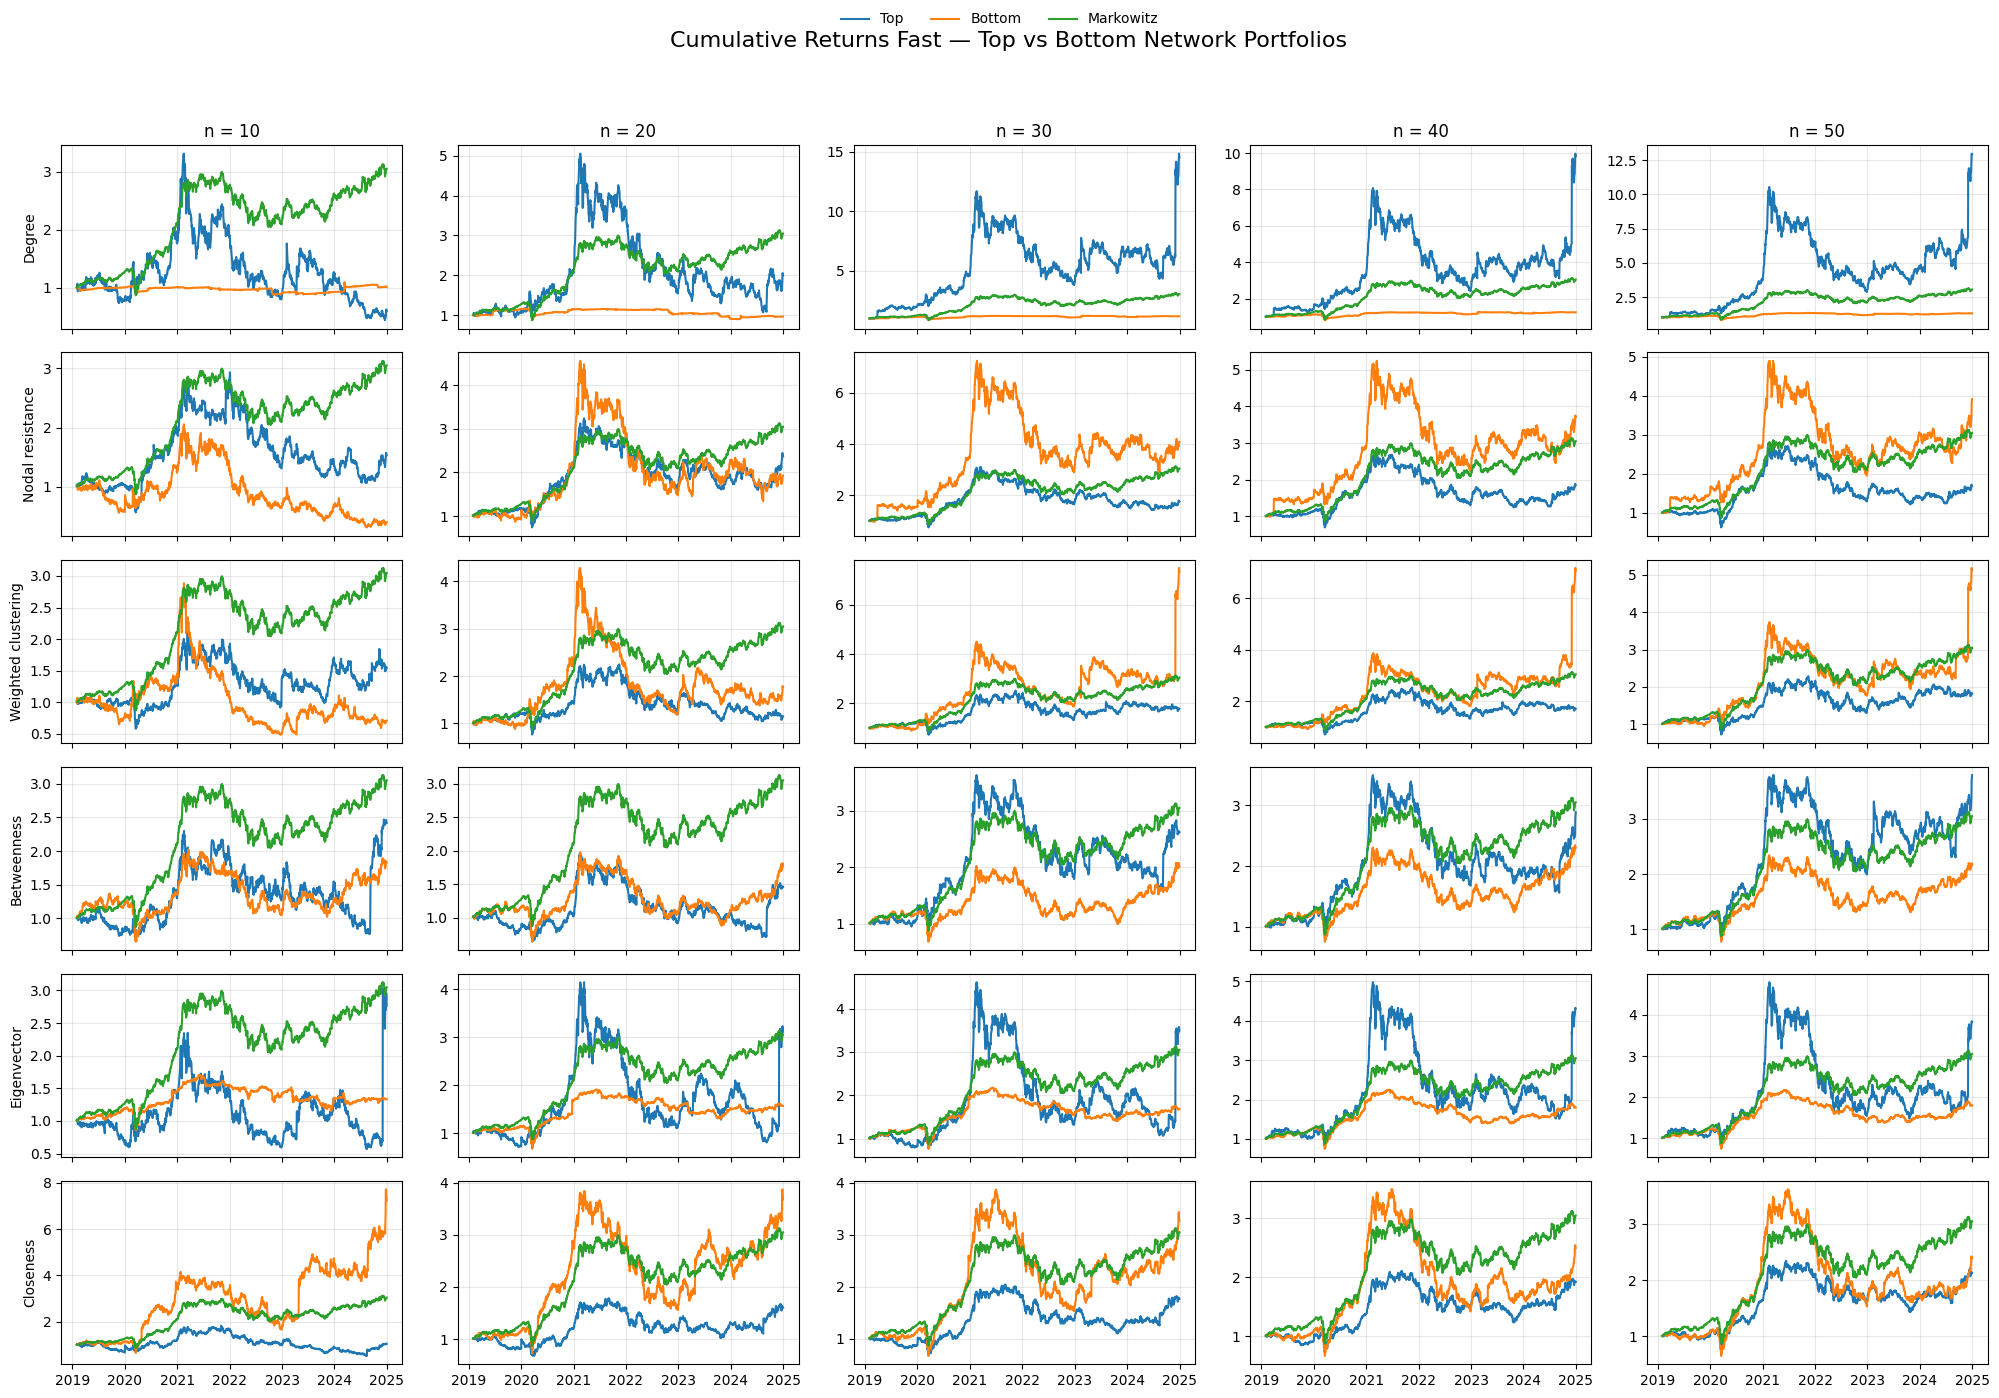

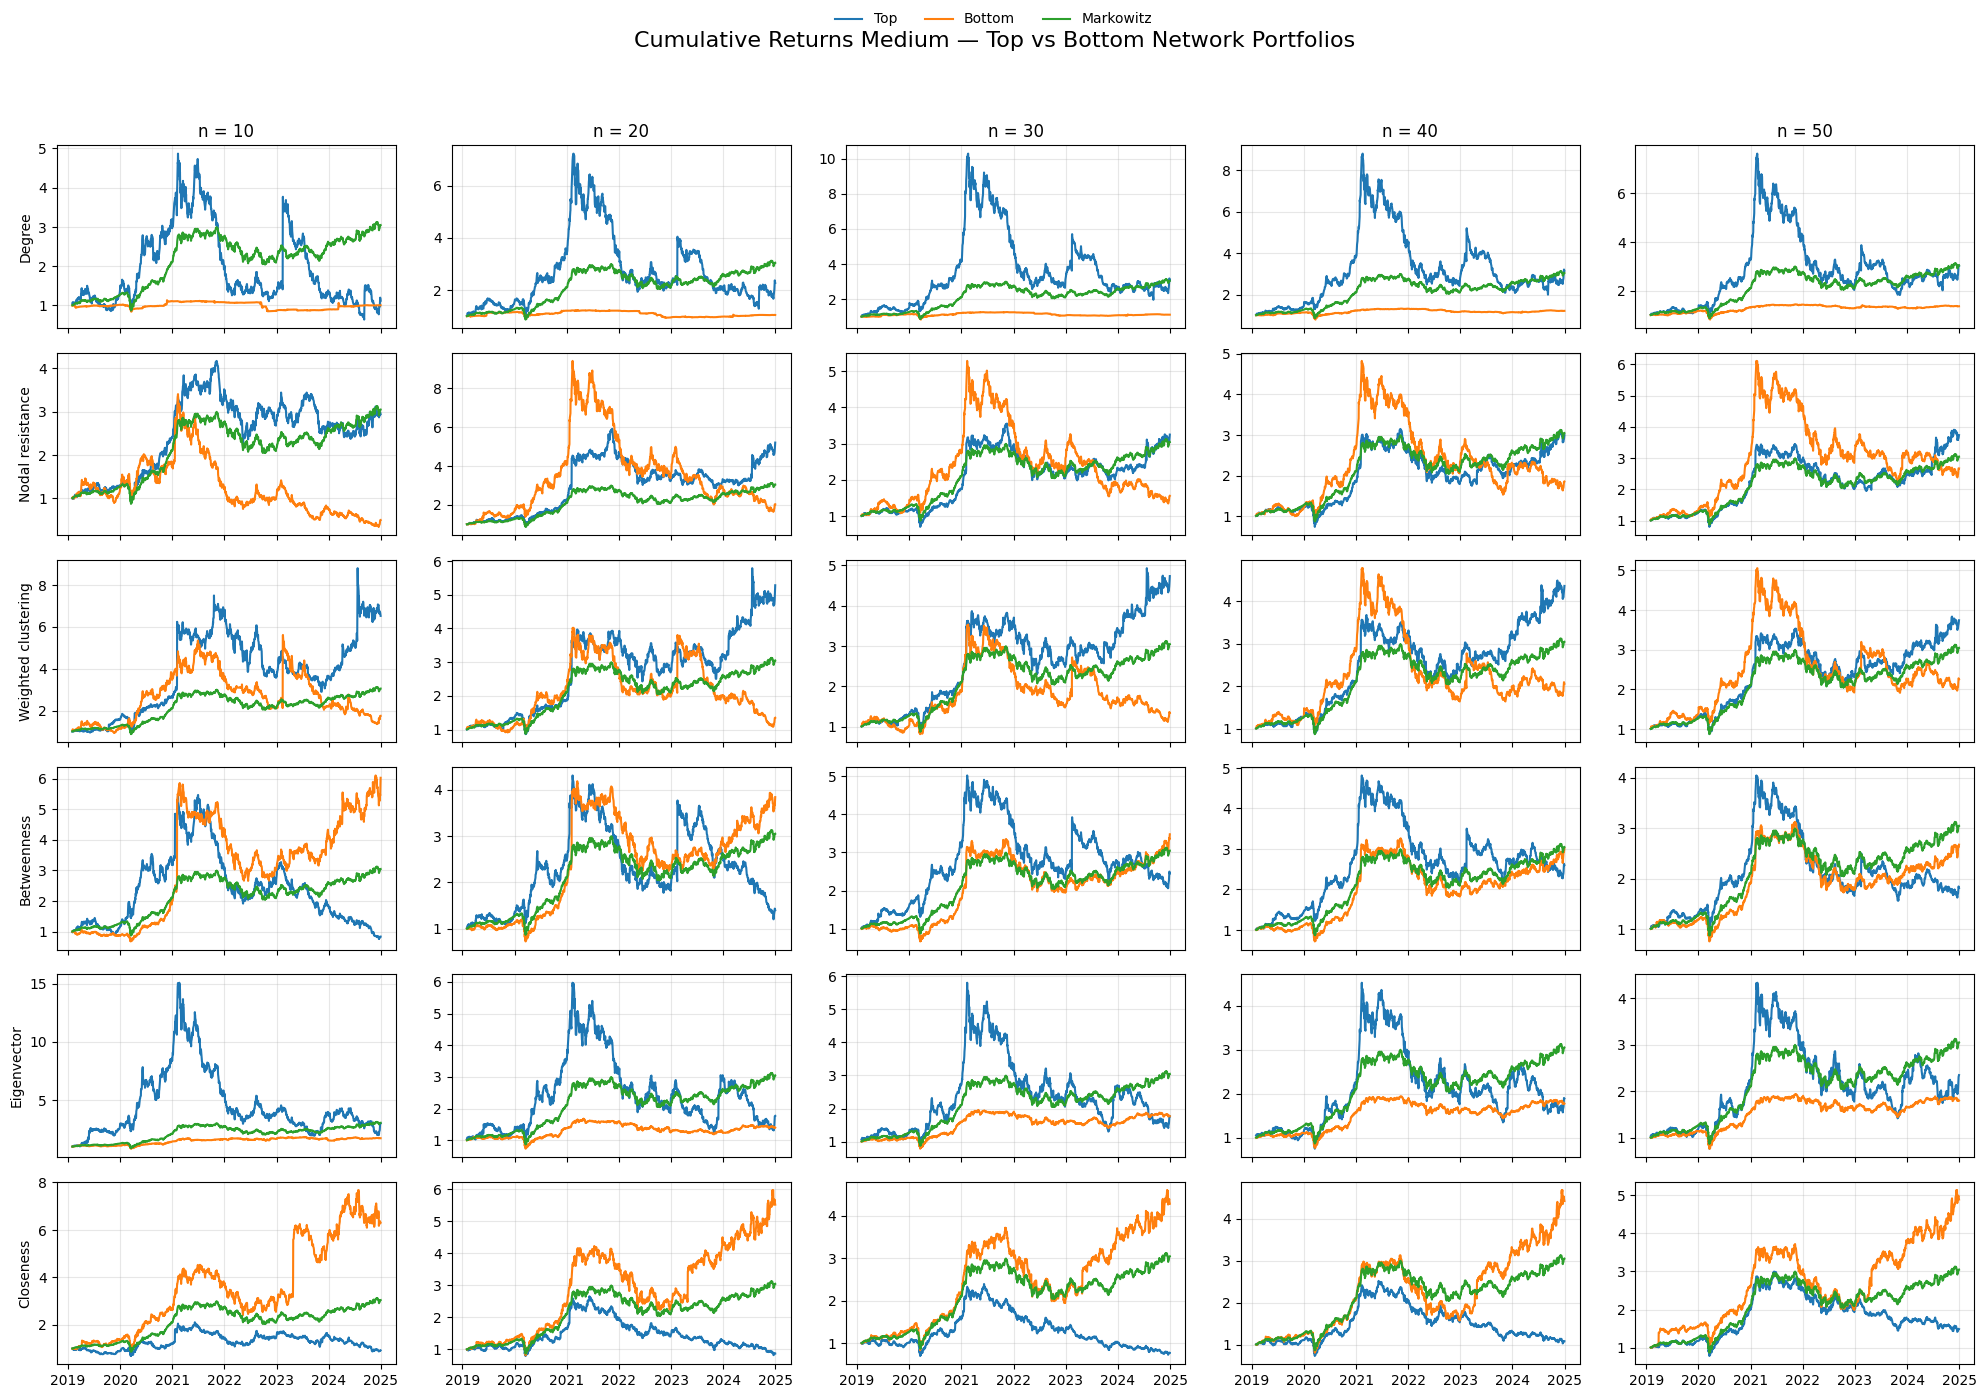

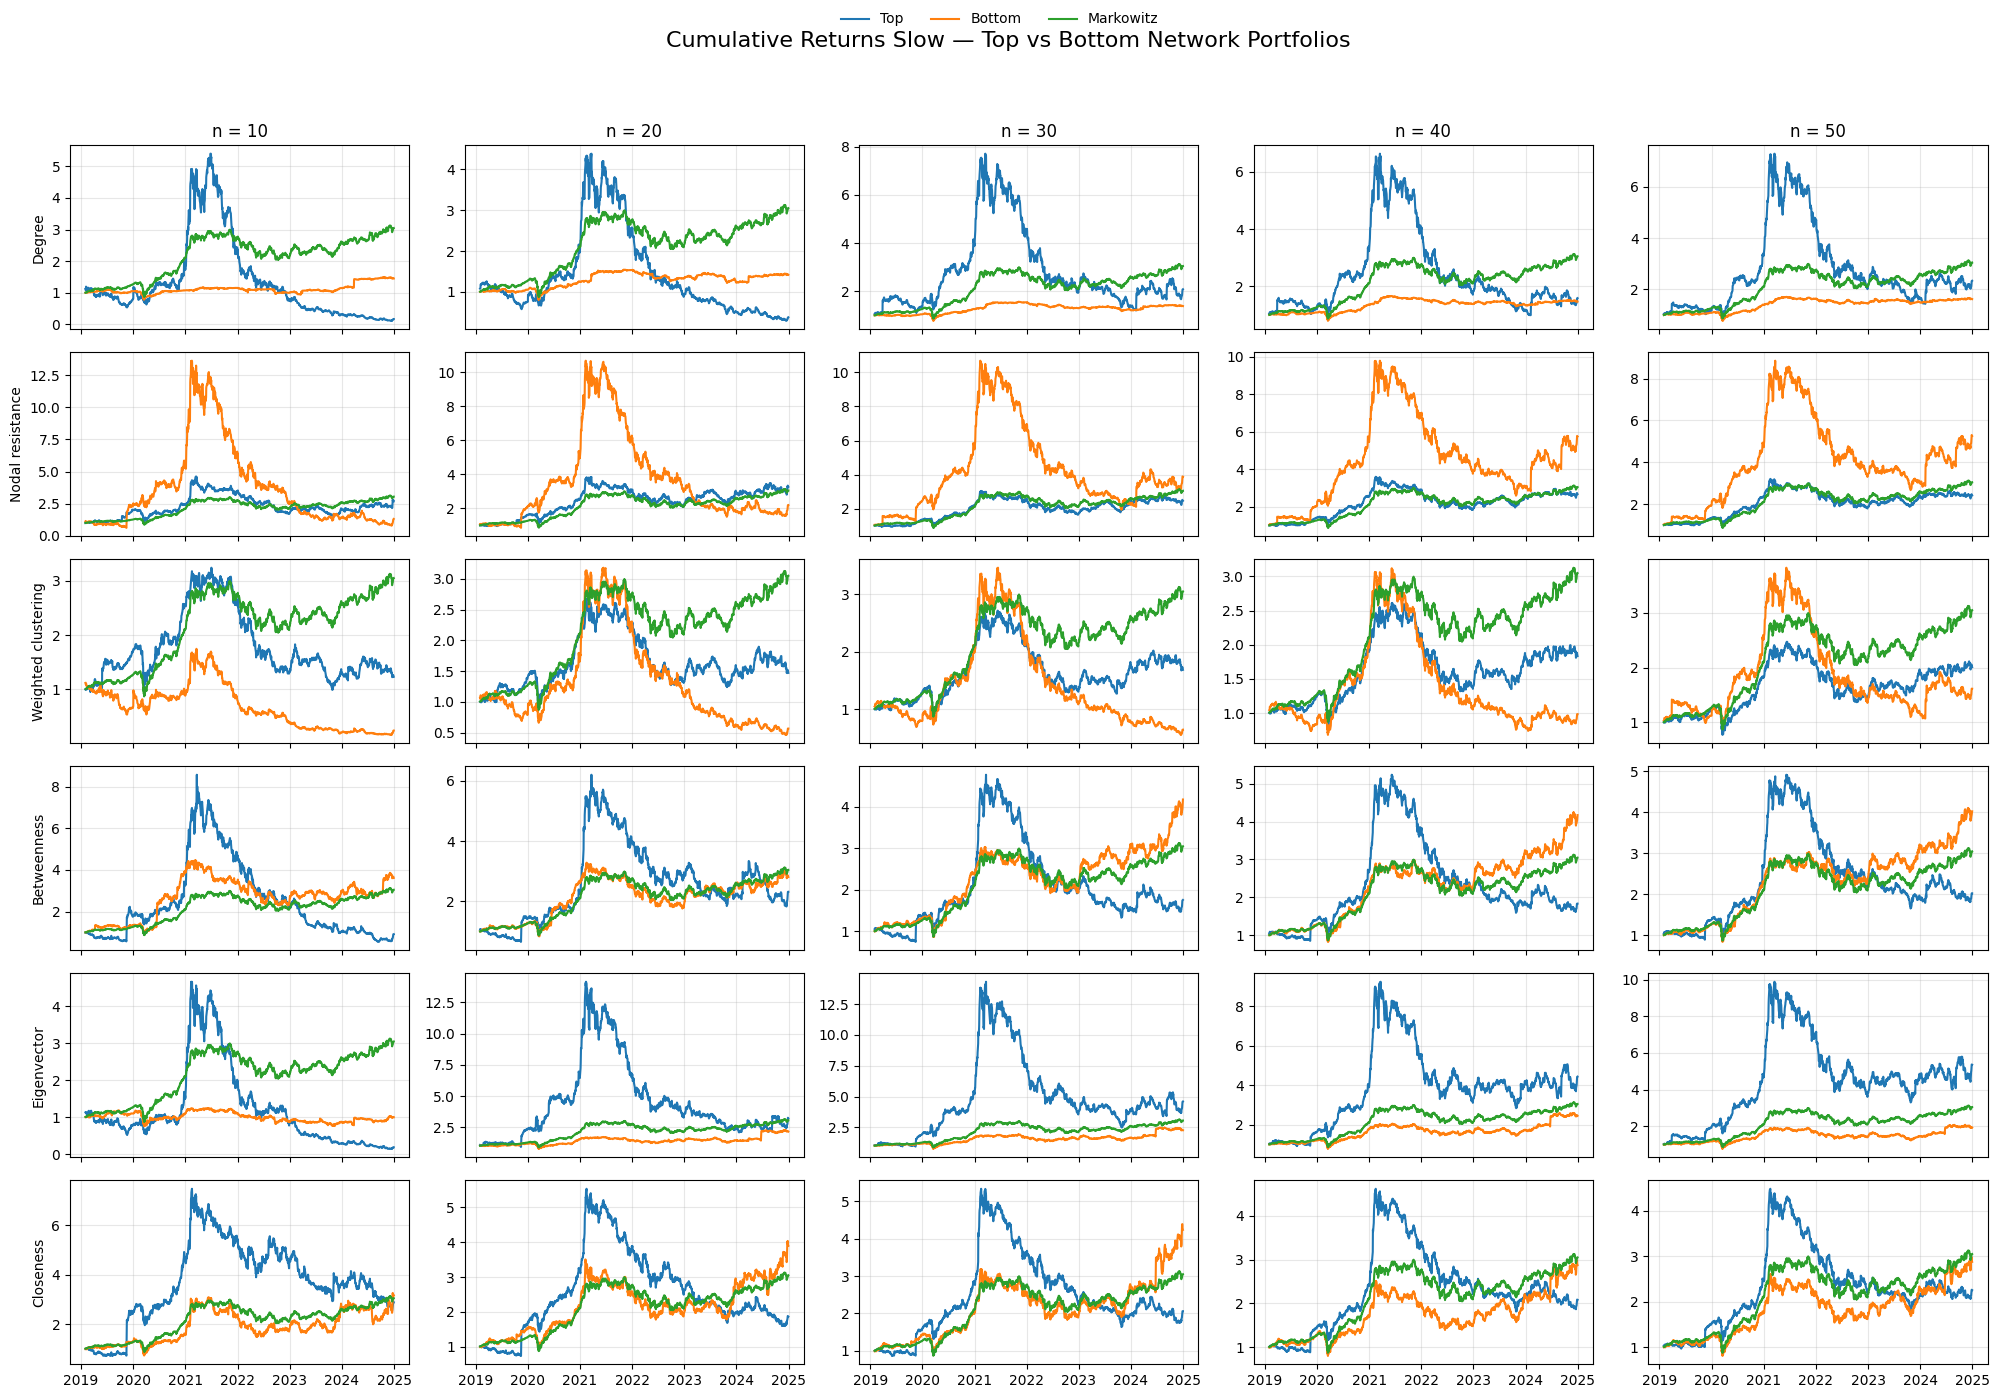

In [269]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("../../data/06_portfolios")

modes = ["Fast", "Medium", "Slow"]

metrics = [
    "degree",
    "nodal_resistance",
    "weighted_clustering",
    "betweenness",
    "eigenvector",
    "closeness",
]

ns = [10, 20, 30, 40, 50]

for mode in modes:
    fig, axes = plt.subplots(
        nrows=len(metrics),
        ncols=len(ns),
        figsize=(20, 14),
        sharex=True,
        sharey=False
    )
    for i, metric in enumerate(metrics):
        for j, n in enumerate(ns):
            ax = axes[i, j]

            top_path = base_dir / f"{mode.lower()}_top_{n}_{metric}_returns.parquet"
            bottom_path = base_dir / f"{mode.lower()}_bottom_{n}_{metric}_returns.parquet"

            if not top_path.exists() or not bottom_path.exists():
                ax.set_visible(False)
                continue

            top = pd.read_parquet(top_path)
            bottom = pd.read_parquet(bottom_path)

            # garantir Series
            if isinstance(top, pd.DataFrame):
                top = top.iloc[:, 0]
            if isinstance(bottom, pd.DataFrame):
                bottom = bottom.iloc[:, 0]

            ax.plot(top.index, top.values, label="Top")
            ax.plot(bottom.index, bottom.values, label="Bottom")
            ax.plot(cr_markowitz.index, cr_markowitz.values, label="Markowitz")

            # títulos
            if i == 0:
                ax.set_title(f"n = {n}")

            if j == 0:
                ax.set_ylabel(metric.replace("_", " ").capitalize())

            ax.grid(True, alpha=0.3)

    # legenda única
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False
    )

    fig.suptitle(
        f"Cumulative Returns {mode} — Top vs Bottom Network Portfolios",
        fontsize=16
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Volatility

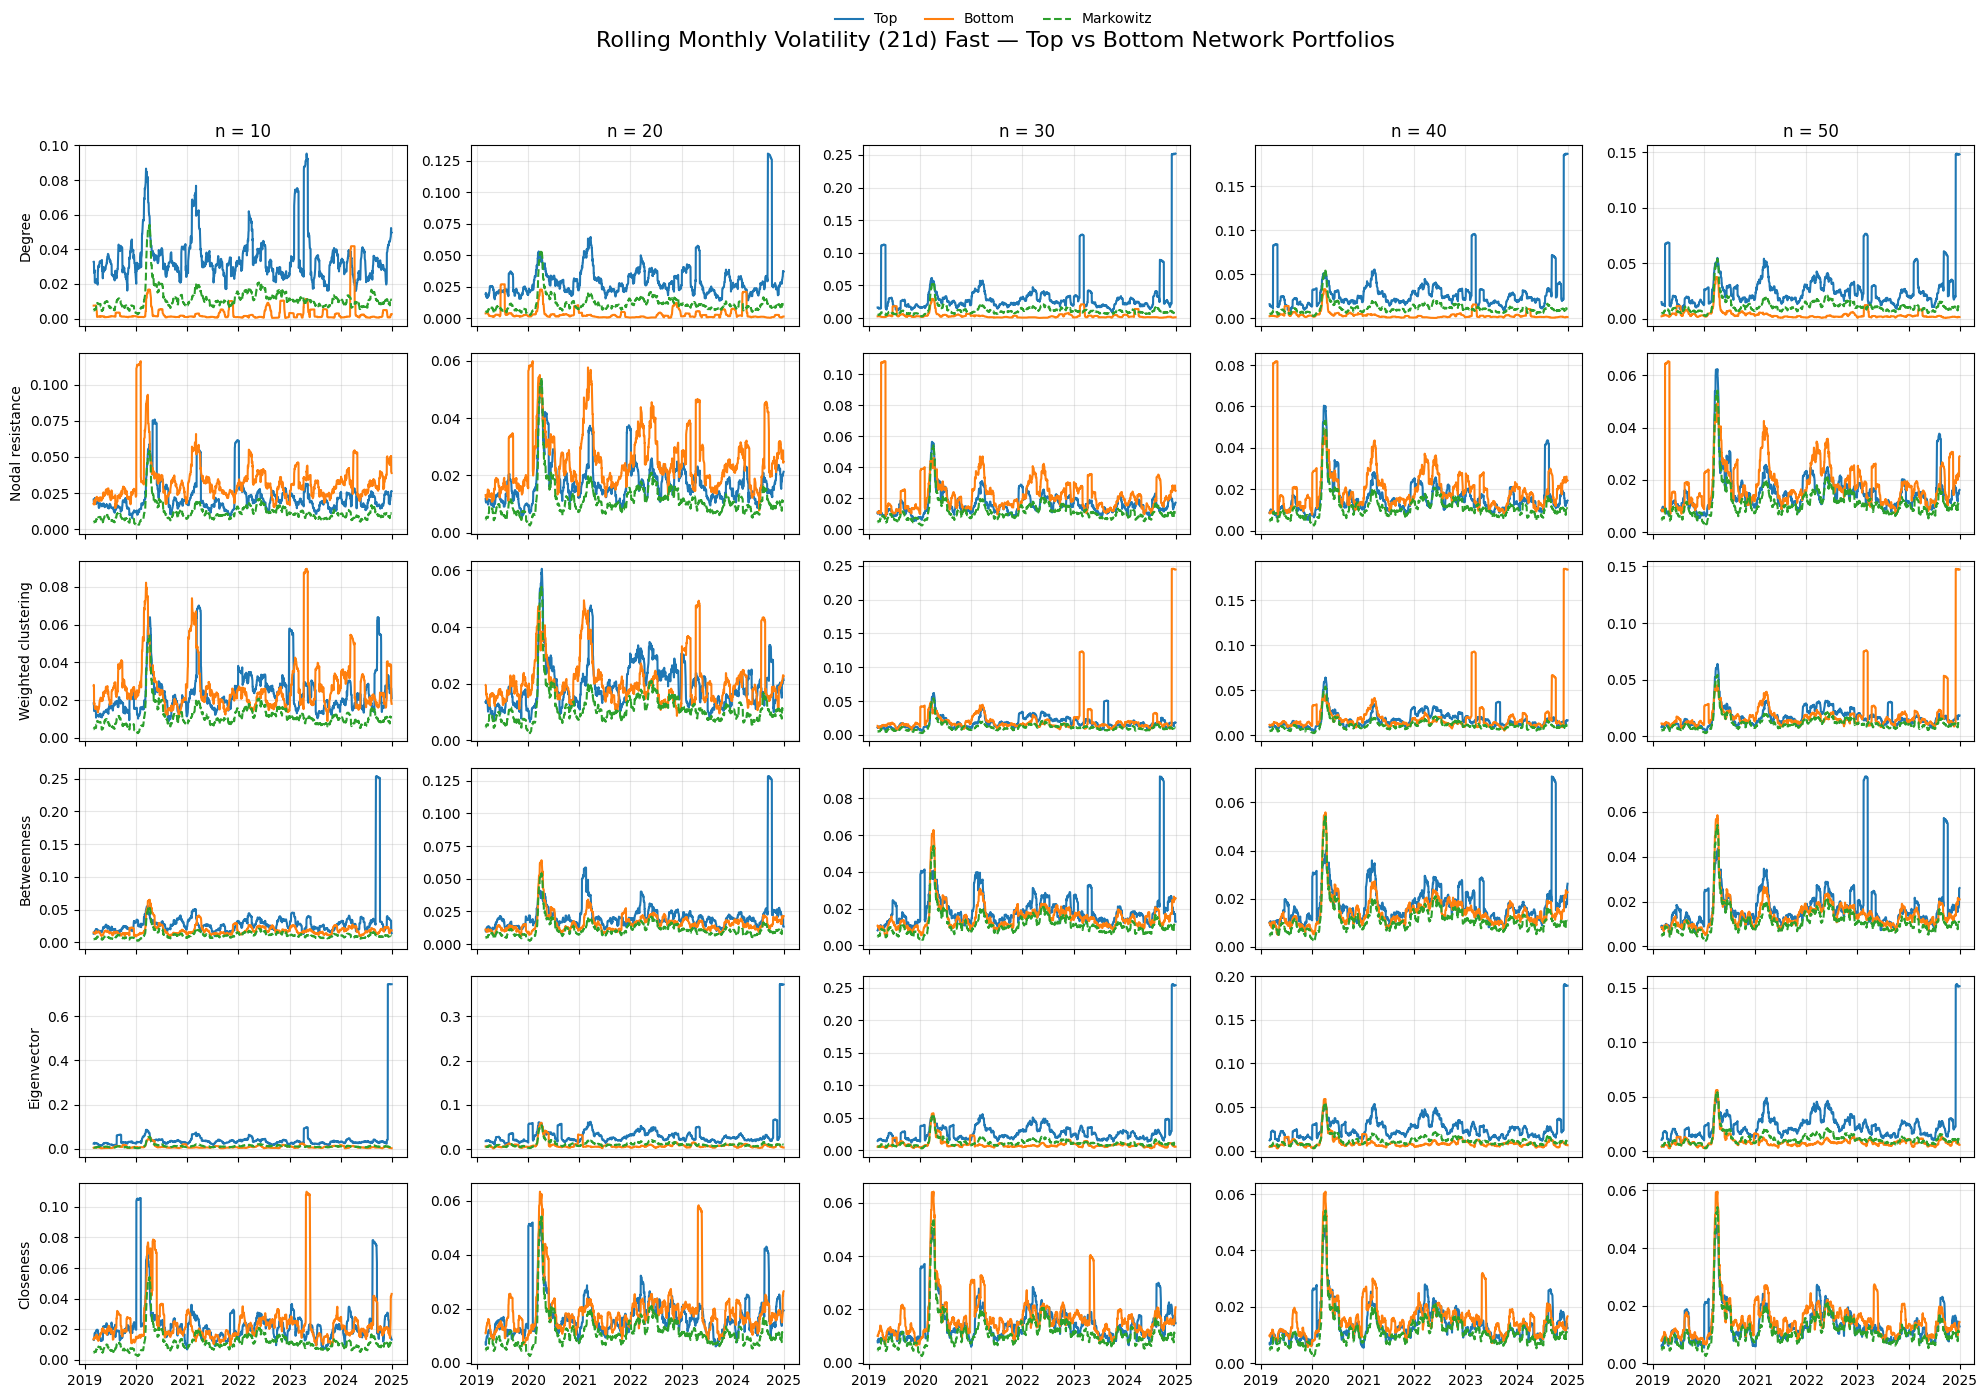

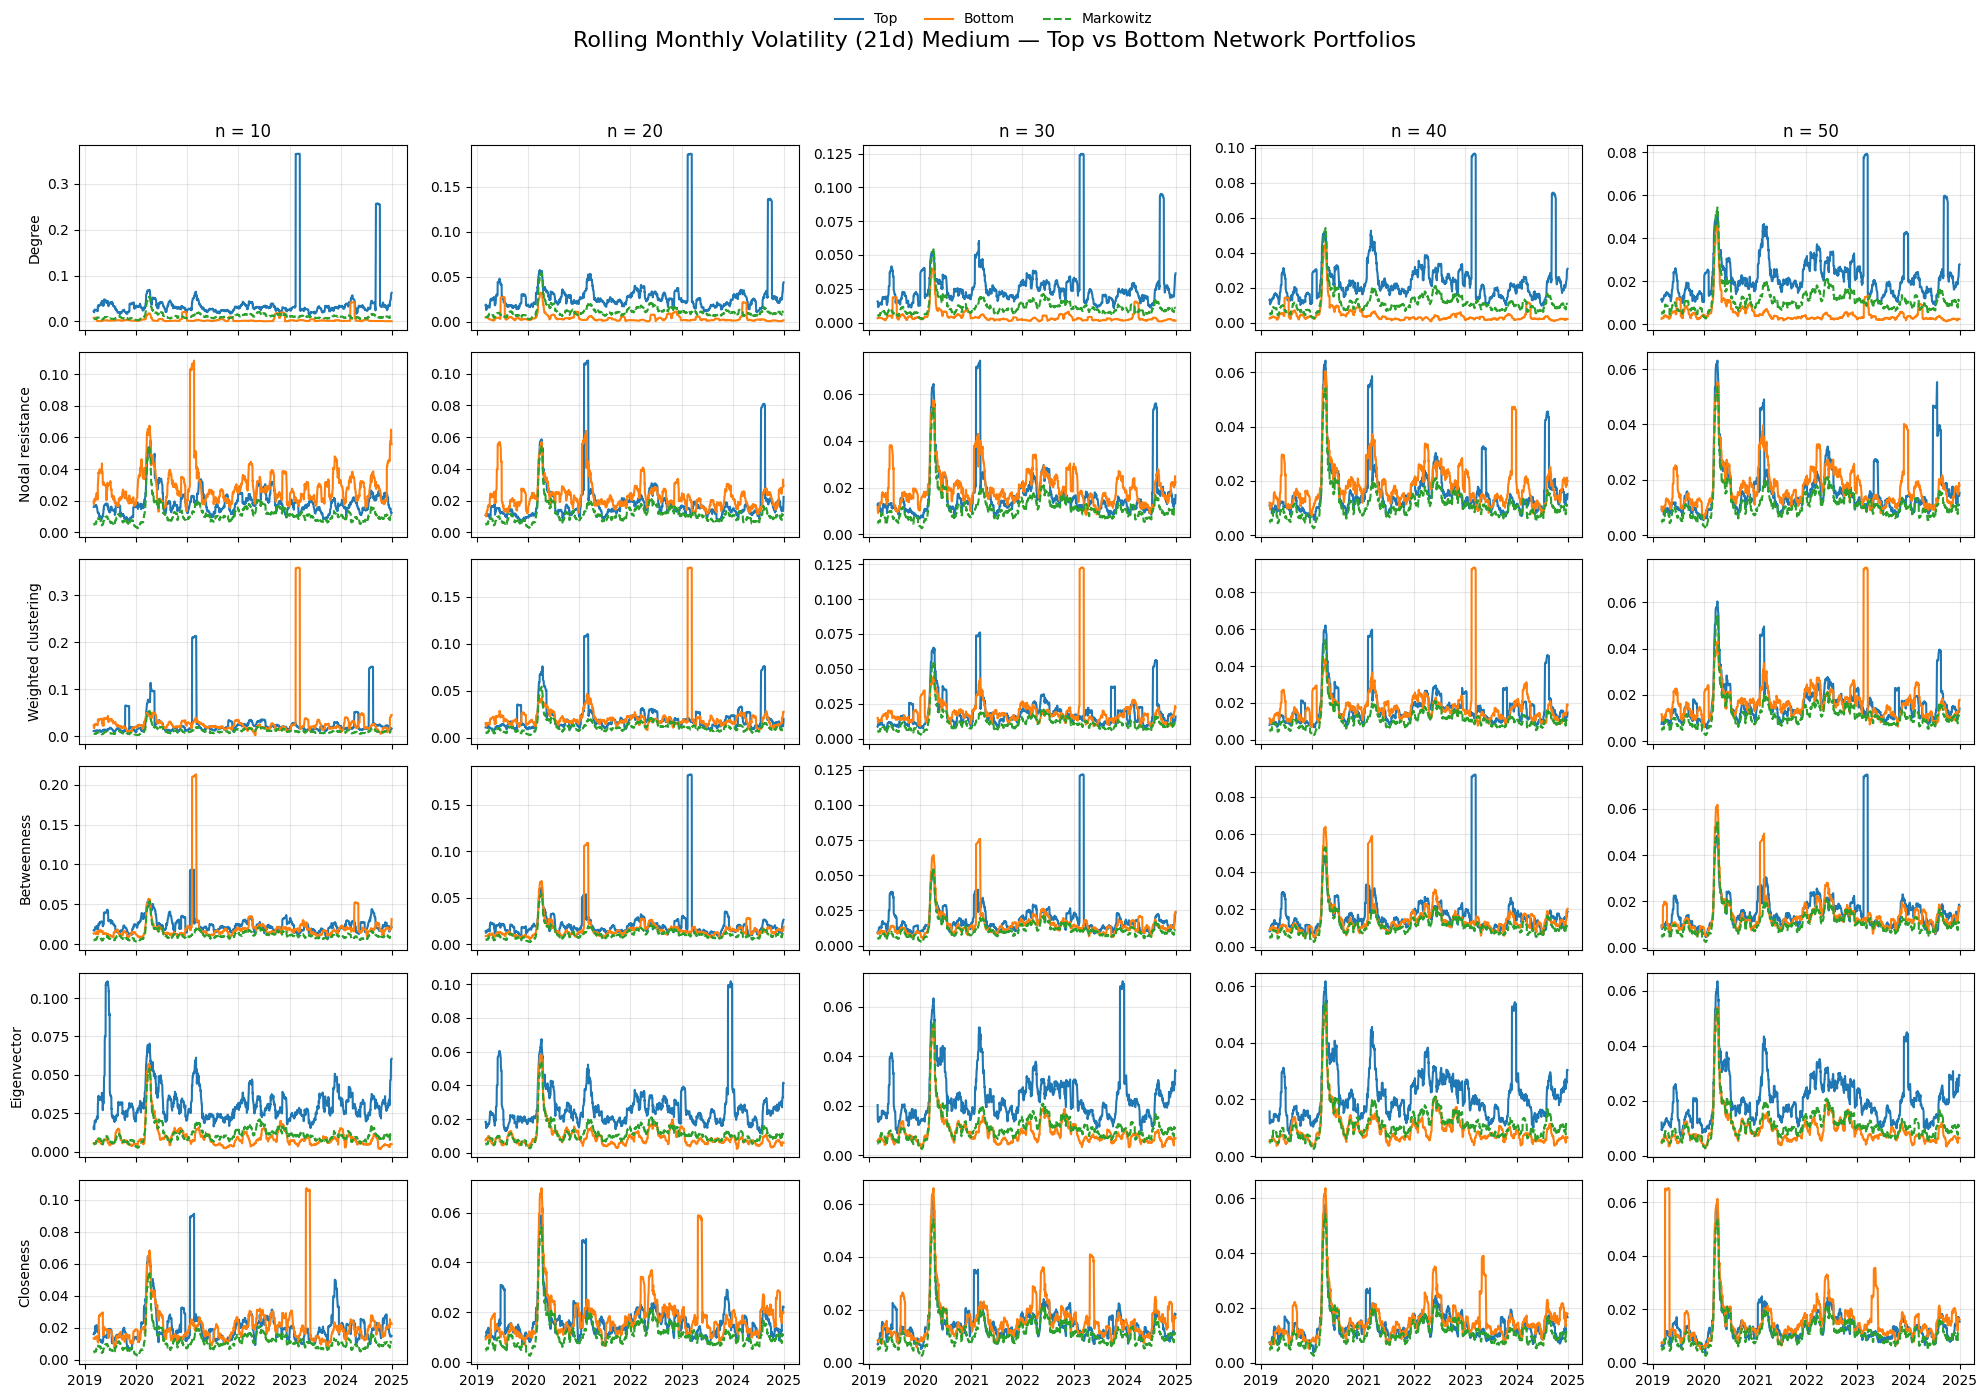

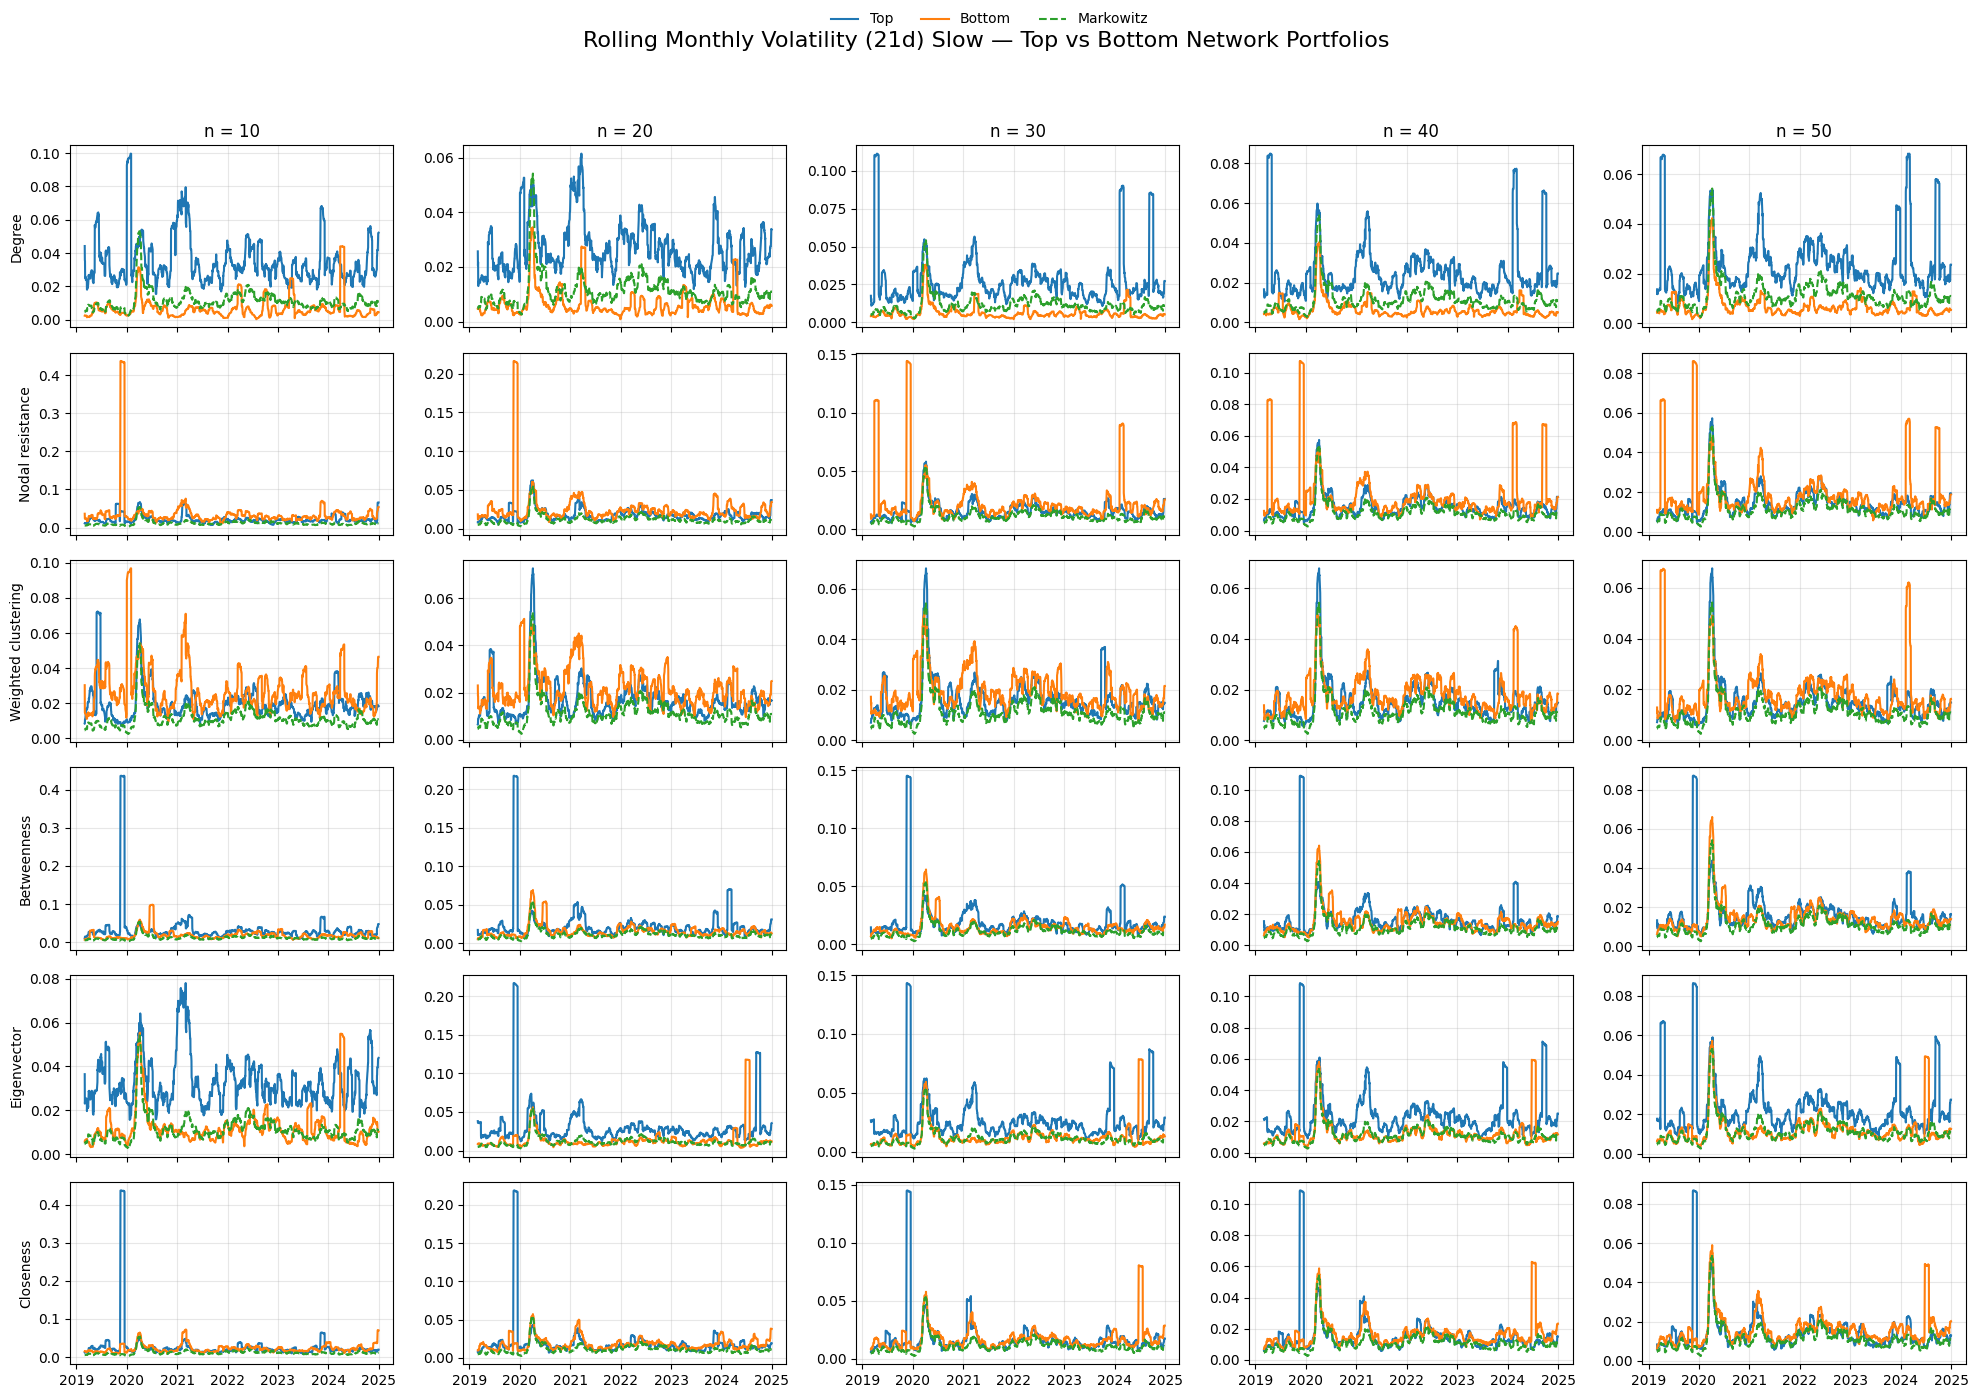

In [273]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("../../data/06_portfolios")

metrics = [
    "degree",
    "nodal_resistance",
    "weighted_clustering",
    "betweenness",
    "eigenvector",
    "closeness",
]

ns = [10, 20, 30, 40, 50]
WINDOW = 21  # ~1 mês

# -------- Markowitz daily returns --------
daily_ret_mkv = (weights_markowitz * returns_test).sum(axis=1)
vol_mkv = daily_ret_mkv.rolling(WINDOW, min_periods=WINDOW).std()

for mode in modes:
    fig, axes = plt.subplots(
        nrows=len(metrics),
        ncols=len(ns),
        figsize=(20, 14),
        sharex=True,
        sharey=False
    )

    for i, metric in enumerate(metrics):
        for j, n in enumerate(ns):
            ax = axes[i, j]

            top_path = base_dir / f"{mode.lower()}_top_{n}_{metric}_portfolio.parquet"
            bottom_path = base_dir / f"{mode.lower()}_bottom_{n}_{metric}_portfolio.parquet"

            if not top_path.exists() or not bottom_path.exists():
                ax.set_visible(False)
                continue

            # -------- carregar portfólios --------
            top_port = pd.read_parquet(top_path)
            bottom_port = pd.read_parquet(bottom_path)

            # -------- EW daily returns --------
            daily_ret_top = top_port.mean(axis=1)
            daily_ret_bot = bottom_port.mean(axis=1)

            # -------- rolling monthly volatility --------
            vol_top = daily_ret_top.rolling(WINDOW, min_periods=WINDOW).std()
            vol_bot = daily_ret_bot.rolling(WINDOW, min_periods=WINDOW).std()

            # -------- plot --------
            ax.plot(vol_top.index, vol_top.values, label="Top")
            ax.plot(vol_bot.index, vol_bot.values, label="Bottom")
            ax.plot(vol_mkv.index, vol_mkv.values, label="Markowitz", linestyle="--")

            # títulos
            if i == 0:
                ax.set_title(f"n = {n}")

            if j == 0:
                ax.set_ylabel(metric.replace("_", " ").capitalize())

            ax.grid(True, alpha=0.3)

    # legenda única
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False
    )

    fig.suptitle(
        f"Rolling Monthly Volatility (21d) {mode} — Top vs Bottom Network Portfolios",
        fontsize=16
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()